# Bayesian Correction of H(z) Cosmic Chronometers Data with Systematic Errors

## Reproduction of Key Results from Kvint et al. (2025)


## 1. Setup and Dependencies

In [ ]:
# Google Colab Setup - Uncomment for Colab environment
# from google.colab import drive
# drive.mount('/content/drive')

# !pip install numpy scipy matplotlib emcee corner pandas

# in powershell run
# python -m notebook --ServerApp.allow_origin="https://colab.research.google.com" --ServerApp.disable_check_xsrf=True --port=8888


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.special import gamma, gammainc
from scipy.optimize import minimize
from numpy.linalg import inv, det
import emcee
import corner
import warnings
warnings.filterwarnings('ignore')

# np.random.seed(42)

## 2. Load H(z) Data from Table I

In [ ]:
print("H(z) Data - Table I ")

z_data = np.array([
    0.070, 0.090, 0.120, 0.170, 0.1791, 0.1993, 0.200, 0.270, 0.280,
    0.3519, 0.3802, 0.400, 0.4004, 0.4247, 0.445, 0.470, 0.4783, 0.480,
    0.5929, 0.6797, 0.750, 0.7812, 0.8754, 0.880, 0.900, 1.037, 1.300,
    1.363, 1.430, 1.530, 1.750, 1.965
])

H_data = np.array([
    69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9, 77.0, 88.8,
    83.0, 83.0, 95.0, 77.0, 87.1, 92.8, 89.0, 80.9, 97.0,
    104.0, 92.0, 98.8, 105.0, 125.0, 90.0, 117.0, 154.0, 168.0,
    160.0, 177.0, 140.0, 202.0, 186.5
])

sigma_H = np.array([
    19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6, 14.0, 36.6,
    14.0, 13.5, 17.0, 10.2, 11.2, 12.9, 50.0, 9.0, 62.0,
    13.0, 8.0, 33.6, 12.0, 17.0, 40.0, 23.0, 20.0, 17.0,
    33.6, 18.0, 14.0, 40.0, 50.4
])

n_data = len(z_data)
print(f"\nData summary:")
print(f"Number of H(z) data points: {n_data}")
print(f"Redshift range: z = {z_data.min():.3f} to {z_data.max():.3f}")
print(f"H(z) range: {H_data.min():.1f} to {H_data.max():.1f} km/s/Mpc")
print(f"Average uncertainty: {sigma_H.mean():.1f} km/s/Mpc")

H(z) Data - Table I 

Data summary:
Number of H(z) data points: 32
Redshift range: z = 0.070 to 1.965
H(z) range: 68.6 to 202.0 km/s/Mpc
Average uncertainty: 21.7 km/s/Mpc


In [ ]:
# print("Constructing Full Covariance Matrix (GitLab-consistent)\n")

# # --- Statistical covariance (diagonal) ---
# C_stat = np.diag(sigma_H**2)

# # --- Load systematic components ---
# data_path = r"C:\Users\Ramagiri Jaidhar\OneDrive - IIT Hyderabad\Desktop\Jaidhar_IITH\Semester 6\Sem 6 project\CCcovariance\data"
# filename = f"{data_path}/data_MM20.dat"

# zmod, imf, slib, sps, spsooo = np.genfromtxt(
#     filename,
#     comments="#",
#     unpack=True
# )

# # Interpolate to data redshifts (convert % → fraction)
# imf_i    = np.interp(z_data, zmod, imf) / 100.0
# slib_i   = np.interp(z_data, zmod, slib) / 100.0
# sps_i    = np.interp(z_data, zmod, sps) / 100.0
# spsooo_i = np.interp(z_data, zmod, spsooo) / 100.0

# # --- Fully correlated systematic covariance matrices ---
# def correlated_cov(frac_err):
#     v = H_data * frac_err
#     return np.outer(v, v)

# C_imf    = correlated_cov(imf_i)
# C_slib   = correlated_cov(slib_i)
# C_sps    = correlated_cov(sps_i)
# C_spsooo = correlated_cov(spsooo_i)

# # --- Total covariance ---
# cov_matrix = C_stat + C_imf + C_slib + C_sps + C_spsooo

# # --- Sanity checks ---
# if not np.allclose(cov_matrix, cov_matrix.T):
#     raise ValueError("Covariance matrix is not symmetric")

# sign, logdet = np.linalg.slogdet(cov_matrix)
# if sign <= 0:
#     raise ValueError("Covariance matrix is not positive definite")


# cov_inv = np.linalg.inv(cov_matrix)

print("using only diagonal Covariance matrix")
cov_matrix = np.diag(sigma_H**2)
cov_inv = np.linalg.inv(C_stat)

print(f"Shape = {cov_matrix.shape}")


using only diagonal Covariance matrix
Shape = (32, 32)


## 3. Cosmological Models and H(z) Functions

In [ ]:
def H_flat_LCDM(z, H0, Omega_m):
    Omega_Lambda = 1.0 - Omega_m
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def H_OLANDM(z, H0, Omega_m, Omega_Lambda):
    Omega_k = 1.0 - Omega_m - Omega_Lambda
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_k * (1 + z)**2 + Omega_Lambda)

z_test = np.linspace(0, 2, 50)
H_flat_test = H_flat_LCDM(z_test, H0=67.1, Omega_m=0.333)
H_open_test = H_OLANDM(z_test, H0=67.2, Omega_m=0.36, Omega_Lambda=0.71)


## 4. Chi-squared and Likelihood Functions

In [ ]:
# Shared chi-squared
def chi2(theta, z, Hz, Cinv, model="flat"):
    if model == "flat":
        H0, Om = theta
        Hz_model = H0 * np.sqrt(Om * (1 + z)**3 + (1 - Om))

    elif model == "olcdm":
        H0, Om, Ol = theta
        Ok = 1.0 - Om - Ol
        Ez2 = Om * (1 + z)**3 + Ok * (1 + z)**2 + Ol
        if np.any(Ez2 <= 0):
            return np.inf
        Hz_model = H0 * np.sqrt(Ez2)

    diff = Hz - Hz_model
    return diff @ Cinv @ diff

# Likelihoods
def loglike_uncorrected(theta, z, Hz, Cinv, model):
    return -0.5 * chi2(theta, z, Hz, Cinv, model)

def loglike_corrected(theta, z, Hz, Cinv, model):
    *cosmo, f = theta
    if f <= 0:
        return -np.inf
    chi2_val = chi2(cosmo, z, Hz, Cinv, model)
    # k = len(z)
    k = 32
    return -k * np.log(f) - 0.5 * chi2_val / f**2

# Priors
def logprior_flat_uncorr(theta):
    H0, Om = theta
    if 50 < H0 < 90 and 0 < Om < 1:
        return 0.0
    return -np.inf

def logprior_olcdm_uncorr(theta):
    H0, Om, Ol = theta
    Ok = 1.0 - Om - Ol
    if 50 < H0 < 90 and 0 < Om < 1.5 and 0 < Ol < 1.5:
        return 0.0
    return -np.inf

def logprior_flat_corr(theta):
    H0, Om, f = theta
    if 50 < H0 < 90 and 0 < Om < 1 and 0.4 < f < 1.2:
        return 0.0
    return -np.inf

def logprior_olcdm_corr(theta):
    H0, Om, Ol, f = theta
    Ok = 1.0 - Om - Ol
    if (
        50 < H0 < 90
        and 0 < Om < 1.5
        and 0 < Ol < 1.5
        and 0.4 < f < 1.2
    ):
        return 0.0
    return -np.inf

# Posteriors

def logpost_flat_uncorr(theta, z, Hz, Cinv):
    lp = logprior_flat_uncorr(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglike_uncorrected(theta, z, Hz, Cinv, "flat")

def logpost_olcdm_uncorr(theta, z, Hz, Cinv):
    lp = logprior_olcdm_uncorr(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglike_uncorrected(theta, z, Hz, Cinv, "olcdm")

def logpost_flat_corr(theta, z, Hz, Cinv):
    lp = logprior_flat_corr(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglike_corrected(theta, z, Hz, Cinv, "flat")

def logpost_olcdm_corr(theta, z, Hz, Cinv):
    lp = logprior_olcdm_corr(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglike_corrected(theta, z, Hz, Cinv, "olcdm")

## 5. Goodness of Fit Analysis

In [ ]:
# Reduced chi-square PDF & CDF

def chi2_nu_pdf(chi2_nu, nu):
    prefactor = (nu**(nu/2)) / (2**(nu/2) * gamma(nu/2))
    return prefactor * chi2_nu**((nu - 2)/2) * np.exp(-nu * chi2_nu / 2)

def chi2_nu_cdf(chi2_nu, nu):
    return gammainc(nu / 2, nu * chi2_nu / 2)

# Flat ΛCDM — uncorrected

res_flat = minimize(
    lambda p: chi2(p, z_data, H_data, cov_inv, "flat"),
    x0=[67.0, 0.3],
    bounds=[(50, 90), (0.0, 1.0)]
)

chi2_flat = res_flat.fun
nu_flat = len(z_data) - 2
chi2_nu_flat = chi2_flat / nu_flat

# OΛCDM — uncorrected

res_open = minimize(
    lambda p: chi2(p, z_data, H_data, cov_inv, "olcdm"),
    x0=[67.0, 0.3, 0.7],
    bounds=[(50, 90), (0.0, 1.5), (0.0, 1.5)]
)

chi2_open = res_open.fun
nu_open = len(z_data) - 3
chi2_nu_open = chi2_open / nu_open

# Output

print("\nFlat ΛCDM:")
print(f"  χ²     = {chi2_flat:.3f}")
print(f"  χ²_ν   = {chi2_nu_flat:.5f}")
print(f"  P(χ²_ν < χ²_ν,obs) = {chi2_nu_cdf(chi2_nu_flat, nu_flat)*100:.2f}%")

print("\nOΛCDM:")
print(f"  χ²     = {chi2_open:.3f}")
print(f"  χ²_ν   = {chi2_nu_open:.5f}")
print(f"  P(χ²_ν < χ²_ν,obs) = {chi2_nu_cdf(chi2_nu_open, nu_open)*100:.2f}%")



Flat ΛCDM:
  χ²     = 14.549
  χ²_ν   = 0.48496
  P(χ²_ν < χ²_ν,obs) = 0.79%

OΛCDM:
  χ²     = 14.505
  χ²_ν   = 0.50017
  P(χ²_ν < χ²_ν,obs) = 1.15%


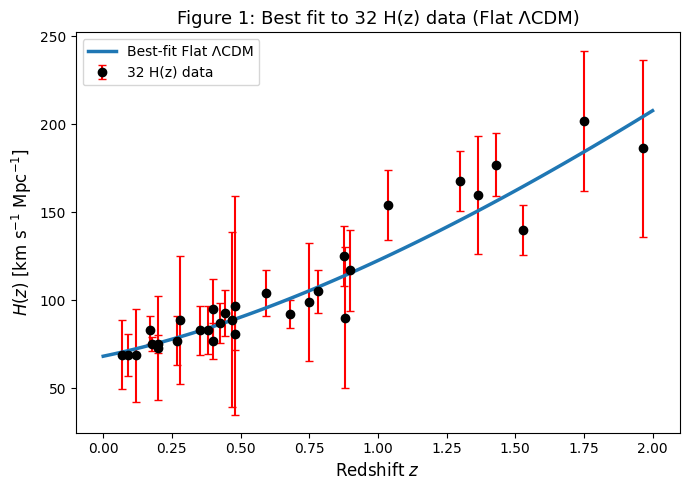

In [ ]:
H0_flat_uncorr, Omega_m_flat_uncorr = res_flat.x

z_plot = np.linspace(0, 2.0, 100)
H_best_flat = H_flat_LCDM(z_plot, H0_flat_uncorr, Omega_m_flat_uncorr)

plt.figure(figsize=(7,5))
plt.errorbar(
    z_data, H_data, yerr=np.sqrt(np.diag(cov_matrix)), #sigma_H
    fmt='o', color='black', ecolor='red', capsize=3, label='32 H(z) data')
plt.plot(z_plot, H_best_flat,lw=2.5, label='Best-fit Flat ΛCDM')

plt.xlabel(r'Redshift $z$', fontsize=12)
plt.ylabel(r'$H(z)$ [km s$^{-1}$ Mpc$^{-1}$]', fontsize=12)
plt.title('Figure 1: Best fit to 32 H(z) data (Flat ΛCDM)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Figure 2 - Chi-squared Distribution (PDF and CDF)

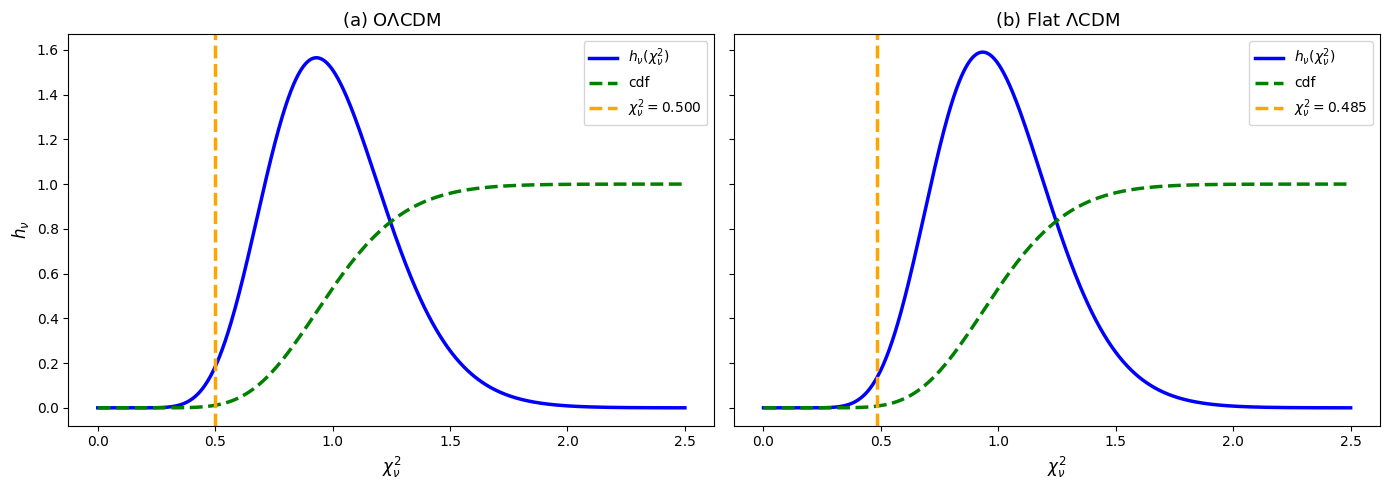

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
chi2_nu_range = np.linspace(0, 2.5, 600)

# (a) OΛCDM
ax = axes[0]
ax.plot(chi2_nu_range, chi2_nu_pdf(chi2_nu_range, nu_open), color="blue", lw=2.5, label=r"$h_\nu(\chi^2_\nu)$")

ax.plot(chi2_nu_range,chi2_nu_cdf(chi2_nu_range, nu_open),color="green", lw=2.5, ls="--", label="cdf")

ax.axvline( chi2_nu_open,color="orange", lw=2.5, ls="--", label=rf"$\chi^2_\nu = {chi2_nu_open:.3f}$")

ax.set_title(r"(a) O$\Lambda$CDM", fontsize=13)
ax.set_xlabel(r"$\chi^2_\nu$", fontsize=12)
ax.set_ylabel(r"$h_\nu$", fontsize=12)
ax.legend()

# (b) Flat ΛCDM
ax = axes[1]

ax.plot(chi2_nu_range, chi2_nu_pdf(chi2_nu_range, nu_flat), color="blue", lw=2.5, label=r"$h_\nu(\chi^2_\nu)$" )

ax.plot( chi2_nu_range, chi2_nu_cdf(chi2_nu_range, nu_flat), color="green", lw=2.5, ls="--", label="cdf" )

ax.axvline( chi2_nu_flat, color="orange", lw=2.5, ls="--", label=rf"$\chi^2_\nu = {chi2_nu_flat:.3f}$" )

ax.set_title(r"(b) Flat $\Lambda$CDM", fontsize=13)
ax.set_xlabel(r"$\chi^2_\nu$", fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()


## 7. MCMC Sampling for Parameter Estimation


In [ ]:
def run_emcee( logpost, p0, args, nsteps, progress=True, move=None ):
    nwalkers, ndim = p0.shape
    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        logpost,
        args=args,
        moves=move or emcee.moves.StretchMove()
    )
    sampler.run_mcmc(p0, nsteps, progress=progress)
    print(f"  Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")
    return sampler


In [ ]:
print("MCMC SAMPLING: UNCORRECTED FLAT ΛCDM MODEL\n")

init_H0_flat = 66.7
init_Omega_m_flat = 0.342

nwalkers_flat = 64
niterations_flat = 10000

# --- Initial walker positions ---
pos_flat_uncorr = np.array([
    [init_H0_flat + np.random.randn()*0.5,
     init_Omega_m_flat + np.random.randn()*0.01]
    for _ in range(nwalkers_flat)
])

# --- Enforce prior bounds ---
pos_flat_uncorr[:, 0] = np.clip(pos_flat_uncorr[:, 0], 50, 90)
pos_flat_uncorr[:, 1] = np.clip(pos_flat_uncorr[:, 1], 0.0, 1.0)

sampler_flat_uncorr = run_emcee(
    logpost=logpost_flat_uncorr,
    p0=pos_flat_uncorr,
    args=(z_data, H_data, cov_inv),
    nsteps=niterations_flat
)

MCMC SAMPLING: UNCORRECTED FLAT ΛCDM MODEL



100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [01:16<00:00, 130.78it/s]

  Mean acceptance fraction: 0.715


In [ ]:
print("MCMC SAMPLING: UNCORRECTED OΛCDM MODEL\n")

init_H0_open = 66.6
init_Omega_m_open = 0.38
init_Omega_L_open = 0.70

nwalkers_open = 64
niterations_open = 10000

# --- Initial walker positions ---
pos_open_uncorr = np.array([
    [init_H0_open + np.random.randn()*0.5,
     init_Omega_m_open + np.random.randn()*0.02,
     init_Omega_L_open + np.random.randn()*0.02]
    for _ in range(nwalkers_open)
])

# --- Enforce prior bounds ---
pos_open_uncorr[:, 0] = np.clip(pos_open_uncorr[:, 0], 50, 90)
pos_open_uncorr[:, 1] = np.clip(pos_open_uncorr[:, 1], 0.0, 1.5)
pos_open_uncorr[:, 2] = np.clip(pos_open_uncorr[:, 2], 0.0, 1.5)

sampler_open_uncorr = run_emcee(
    logpost=logpost_olcdm_uncorr,
    p0=pos_open_uncorr,
    args=(z_data, H_data, cov_inv),
    nsteps=niterations_open
)


MCMC SAMPLING: UNCORRECTED OΛCDM MODEL



100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:41<00:00, 98.85it/s]

  Mean acceptance fraction: 0.629


In [ ]:
print("MCMC SAMPLING: FLAT ΛCDM MODEL\n")

init_H0_flat = 67.1
init_Omega_m_flat = 0.333
init_f_flat = 0.728

nwalkers_flat = 64
niterations_flat = 10000


pos_flat = np.array([
    [init_H0_flat + np.random.randn()*0.5,
     init_Omega_m_flat + np.random.randn()*0.02,
     init_f_flat + np.random.randn()*0.08]
    for _ in range(nwalkers_flat)
])

# Ensure starting points are inside the likelihood priors only
pos_flat[:, 0] = np.clip(pos_flat[:, 0], 50, 150)
pos_flat[:, 1] = np.clip(pos_flat[:, 1], 0.0, 1.0)
pos_flat[:, 2] = np.clip(pos_flat[:, 2], 0.0, 2.0)

sampler_flat = run_emcee(
    logpost=logpost_flat_corr,
    p0=pos_flat,
    args=(z_data, H_data, cov_inv),
    nsteps=niterations_flat
)


MCMC SAMPLING: FLAT ΛCDM MODEL



100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [01:21<00:00, 123.19it/s]

  Mean acceptance fraction: 0.643


In [ ]:
print("MCMC SAMPLING: OΛCDM MODEL\n")

init_H0_open = 67.2
init_Omega_m_open = 0.36
init_Omega_L_open = 0.71
init_f_open = 0.74

nwalkers_open = 64
niterations_open = 10000

pos_open = np.array([
    [init_H0_open + np.random.randn()*0.5,
     init_Omega_m_open + np.random.randn()*0.04,
     init_Omega_L_open + np.random.randn()*0.06,
     init_f_open + np.random.randn()*0.08]
    for _ in range(nwalkers_open)
])

pos_open[:, 0] = np.clip(pos_open[:, 0], 50, 150)
pos_open[:, 1] = np.clip(pos_open[:, 1], 0.0, 1.0)
pos_open[:, 2] = np.clip(pos_open[:, 2], -1.0, 2.0)
pos_open[:, 3] = np.clip(pos_open[:, 3], 0.0, 2.0)

sampler_open = run_emcee(
    logpost=logpost_olcdm_corr,
    p0=pos_open,
    args=(z_data, H_data, cov_inv),
    nsteps=niterations_open
)


MCMC SAMPLING: OΛCDM MODEL



100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:49<00:00, 91.17it/s]

  Mean acceptance fraction: 0.581


In [ ]:
burn_in = 3000

def summarize_posterior(samples):
    mean = np.mean(samples)
    p68 = np.percentile(samples, [16, 84])
    p95 = np.percentile(samples, [2.5, 97.5])

    return {
        "center": mean,
        "p68": p68,
        "p95": p95,
        "err+_68": p68[1] - mean,
        "err-_68": mean - p68[0],
        "err+_95": p95[1] - mean,
        "err-_95": mean - p95[0],
    }

def results_table(results):
    rows = []
    for name, r in results.items():
        rows.append({
            "parameter": name,
            "mean": r["center"],
            "+68%": r["err+_68"],
            "-68%": r["err-_68"],
            "+95%": r["err+_95"],
            "-95%": r["err-_95"],
        })
    return pd.DataFrame(rows)


In [ ]:
# print('acceptance_fraction')
# print( f"sampler_flat_uncorr = {np.mean(sampler_flat_uncorr.acceptance_fraction)}")
# print( f"sampler_open_uncorr = {np.mean(sampler_open_uncorr.acceptance_fraction)}")
# print( f"sampler_flat = {np.mean(sampler_flat.acceptance_fraction)}")
# print( f"sampler_open = {np.mean(sampler_open.acceptance_fraction)}")


In [ ]:
# --- Extract uncorrected flat ΛCDM samples ---
chain_flat_uncorr = sampler_flat_uncorr.get_chain(
    discard=burn_in,   # safer burn-in
    thin=10,        # reduce autocorrelation
    flat=True
)


H0_samples_flat_uncorr = chain_flat_uncorr[:, 0]
Omega_m_samples_flat_uncorr = chain_flat_uncorr[:, 1]

# --- mean-based summaries ---
H0_flat_uncorr = summarize_posterior(H0_samples_flat_uncorr)
Omega_m_flat_uncorr = summarize_posterior(Omega_m_samples_flat_uncorr)

results_flat_uncorr = {
    "H0": H0_flat_uncorr,
    "Omega_m": Omega_m_flat_uncorr
}
df_flat_uncorr = results_table(results_flat_uncorr)
print("RESULTS: FLAT ΛCDM MODEL (UNCORRECTED)")
display(df_flat_uncorr)


RESULTS: FLAT ΛCDM MODEL (UNCORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,67.685885,3.045826,3.050659,5.903934,6.147701
1,Omega_m,0.332770,0.060077,0.060243,0.135230,0.106890


In [ ]:
# --- Extract uncorrected OΛCDM samples ---
chain_open_uncorr = sampler_open_uncorr.get_chain(
    discard=burn_in,   # safer burn-in
    thin=10,        # reduce autocorrelation
    flat=True
)


H0_samples_open_uncorr = chain_open_uncorr[:, 0]
Omega_m_samples_open_uncorr = chain_open_uncorr[:, 1]
Omega_L_samples_open_uncorr = chain_open_uncorr[:, 2]

# Derived curvature
Omega_k_samples_open_uncorr = (
    1.0 - Omega_m_samples_open_uncorr - Omega_L_samples_open_uncorr
)

# --- mean-based summaries ---
H0_open_uncorr = summarize_posterior(H0_samples_open_uncorr)
Omega_m_open_uncorr = summarize_posterior(Omega_m_samples_open_uncorr)
Omega_L_open_uncorr = summarize_posterior(Omega_L_samples_open_uncorr)
Omega_k_open_uncorr = summarize_posterior(Omega_k_samples_open_uncorr)

results_open_uncorr = {
    "H0": H0_open_uncorr,
    "Omega_m": Omega_m_open_uncorr,
    "Omega_Lambda": Omega_L_open_uncorr,
    "Omega_k": Omega_k_open_uncorr
}
df_open_uncorr = results_table(results_open_uncorr)

print("RESULTS: OΛCDM MODEL (UNCORRECTED)")
display(df_open_uncorr)




RESULTS: OΛCDM MODEL (UNCORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,68.225219,4.597477,4.565086,9.008054,8.129647
1,Omega_m,0.356606,0.177799,0.182168,0.333574,0.307579
2,Omega_Lambda,0.710218,0.364333,0.370827,0.637566,0.627074
3,Omega_k,-0.066824,0.538589,0.529094,0.883659,0.937051


In [ ]:
# --- Extract flat ΛCDM samples ---
chain_flat_uncorr = sampler_flat.get_chain(
    discard=burn_in,   # safer burn-in
    thin=10,        # reduce autocorrelation
    flat=True
)

H0_samples_flat = chain_flat_uncorr[:, 0]
Omega_m_samples_flat = chain_flat_uncorr[:, 1]
f_samples_flat = chain_flat_uncorr[:, 2]

# --- mean-based summaries ---
H0_flat = summarize_posterior(H0_samples_flat)
Omega_m_flat = summarize_posterior(Omega_m_samples_flat)
f_flat = summarize_posterior(f_samples_flat)


results_flat_corr = {
    "H0": H0_flat,
    "Omega_m": Omega_m_flat,
    "f": f_flat
}

df_flat_corr = results_table(results_flat_corr)

print("RESULTS: FLAT ΛCDM MODEL (CORRECTED)")
display(df_flat_corr)


RESULTS: FLAT ΛCDM MODEL (CORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,67.906030,2.210445,2.205115,4.393226,4.601511
1,Omega_m,0.326152,0.042876,0.043166,0.096844,0.079921
2,f,0.728377,0.095676,0.095713,0.223326,0.163523


In [ ]:
# --- Extract OΛCDM samples ---
chain_flat_open = sampler_open.get_chain(
    discard=burn_in,   # safer burn-in
    thin=10,        # reduce autocorrelation
    flat=True
)

H0_samples_open = chain_flat_open[:, 0]
Omega_m_samples_open = chain_flat_open[:, 1]
Omega_L_samples_open = chain_flat_open[:, 2]
f_samples_open = chain_flat_open[:, 3]

# Derived curvature
Omega_k_samples_open = 1.0 - Omega_m_samples_open - Omega_L_samples_open

# --- mean-based summaries ---
H0_open = summarize_posterior(H0_samples_open)
Omega_m_open = summarize_posterior(Omega_m_samples_open)
Omega_L_open = summarize_posterior(Omega_L_samples_open)
Omega_k_open = summarize_posterior(Omega_k_samples_open)
f_open = summarize_posterior(f_samples_open)

results_open_corr = {
    "H0": H0_open,
    "Omega_m": Omega_m_open,
    "Omega_Lambda": Omega_L_open,
    "Omega_k": Omega_k_open,
    "f": f_open
}

df_open_corr = results_table(results_open_corr)
print("RESULTS: OΛCDM MODEL (CORRECTED)")
display(df_open_corr)



RESULTS: OΛCDM MODEL (CORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,68.371557,3.663272,3.691848,7.217799,6.959704
1,Omega_m,0.344852,0.145951,0.150921,0.273222,0.281297
2,Omega_Lambda,0.707520,0.299494,0.313849,0.537912,0.589870
3,Omega_k,-0.052372,0.457133,0.438847,0.840073,0.795543
4,f,0.735752,0.096793,0.096346,0.223831,0.165579


In [ ]:
print("RESULTS: FLAT ΛCDM MODEL (UNCORRECTED)")
display(df_flat_uncorr)

print("\nRESULTS: FLAT ΛCDM MODEL (CORRECTED)")
display(df_flat_corr)

print("\nRESULTS: OΛCDM MODEL (UNCORRECTED)")
display(df_open_uncorr)

print("\nRESULTS: OΛCDM MODEL (CORRECTED)")
display(df_open_corr)


RESULTS: FLAT ΛCDM MODEL (UNCORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,67.685885,3.045826,3.050659,5.903934,6.147701
1,Omega_m,0.332770,0.060077,0.060243,0.135230,0.106890



RESULTS: FLAT ΛCDM MODEL (CORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,67.906030,2.210445,2.205115,4.393226,4.601511
1,Omega_m,0.326152,0.042876,0.043166,0.096844,0.079921
2,f,0.728377,0.095676,0.095713,0.223326,0.163523



RESULTS: OΛCDM MODEL (UNCORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,68.225219,4.597477,4.565086,9.008054,8.129647
1,Omega_m,0.356606,0.177799,0.182168,0.333574,0.307579
2,Omega_Lambda,0.710218,0.364333,0.370827,0.637566,0.627074
3,Omega_k,-0.066824,0.538589,0.529094,0.883659,0.937051



RESULTS: OΛCDM MODEL (CORRECTED)


,parameter,mean,+68%,-68%,+95%,-95%
0,H0,68.371557,3.663272,3.691848,7.217799,6.959704
1,Omega_m,0.344852,0.145951,0.150921,0.273222,0.281297
2,Omega_Lambda,0.707520,0.299494,0.313849,0.537912,0.589870
3,Omega_k,-0.052372,0.457133,0.438847,0.840073,0.795543
4,f,0.735752,0.096793,0.096346,0.223831,0.165579


## 8. Figure 3 - Flat ΛCDM Posterior Contours (Corner Plot)

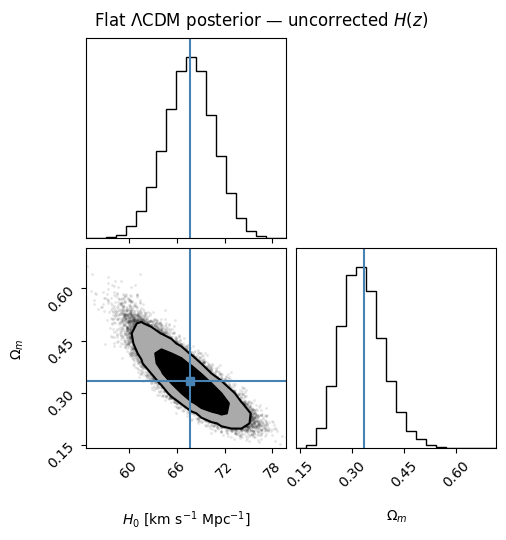

In [ ]:
samples_flat_uncorr = np.column_stack((
    H0_samples_flat_uncorr,
    Omega_m_samples_flat_uncorr
))

fig = corner.corner(
    samples_flat_uncorr,
    labels=[r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$\Omega_m$"],
    truths=[
        H0_flat_uncorr["center"],
        Omega_m_flat_uncorr["center"]
    ],
    levels=[0.68, 0.95],
    fill_contours=True
)

fig.suptitle(r"Flat $\Lambda$CDM posterior — uncorrected $H(z)$ ")
plt.show()


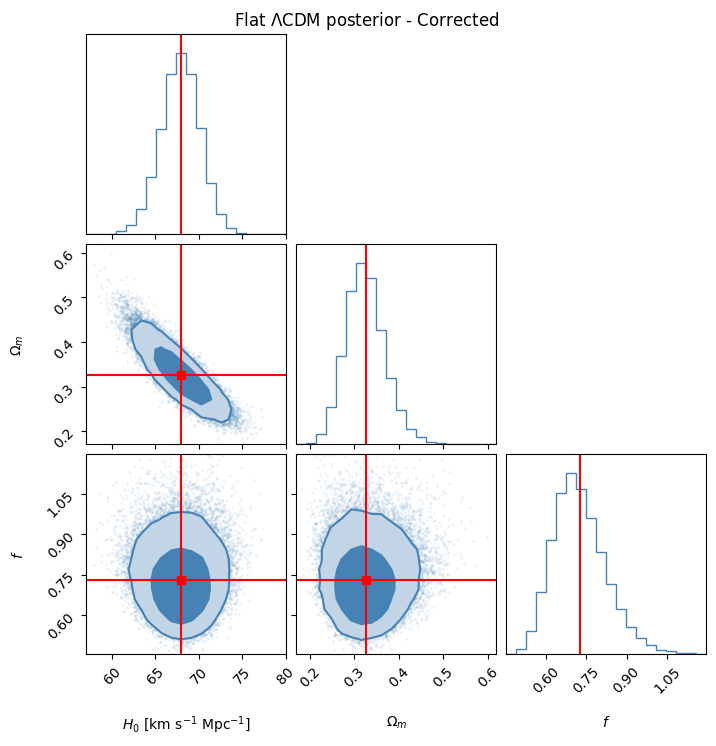

In [ ]:
samples_flat = np.column_stack((
    H0_samples_flat,
    Omega_m_samples_flat,
    f_samples_flat
))

fig = corner.corner(
    samples_flat,
    labels=[r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$\Omega_m$", r"$f$"],
    truths=[H0_flat["center"], Omega_m_flat["center"], f_flat["center"]],
    truth_color='red',
    color='steelblue',
    levels=[0.68, 0.95],
    fill_contours=True
)

fig.suptitle(r"Flat $\Lambda$CDM posterior - Corrected")

plt.show()


## 9. Figure 4 - OΛCDM Posterior Contours (Corner Plot)

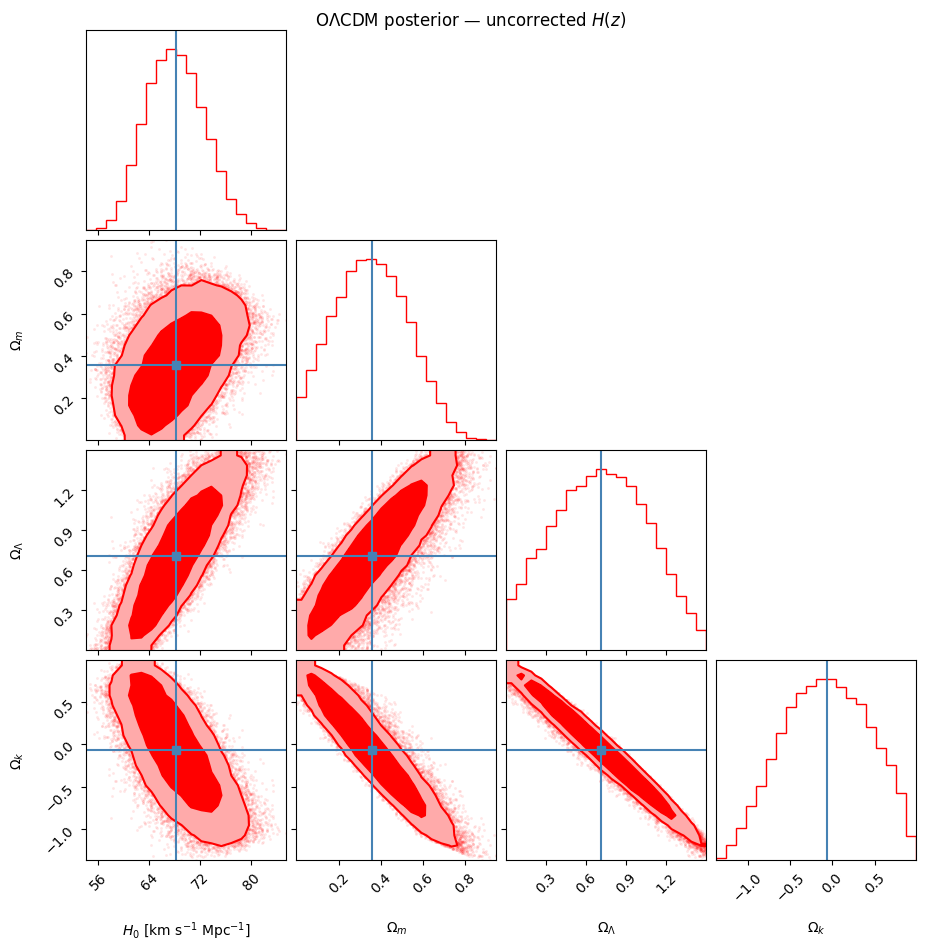

In [ ]:
samples_open_uncorr = np.column_stack((
    H0_samples_open_uncorr,
    Omega_m_samples_open_uncorr,
    Omega_L_samples_open_uncorr,
    Omega_k_samples_open_uncorr
))

fig = corner.corner(
    samples_open_uncorr,
    labels=[
        r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]",
        r"$\Omega_m$",
        r"$\Omega_\Lambda$",
        r"$\Omega_k$"
    ],
    truths=[
        H0_open_uncorr["center"],
        Omega_m_open_uncorr["center"],
        Omega_L_open_uncorr["center"],
        Omega_k_open_uncorr["center"]
    ],
    levels=[0.68, 0.95],
    # truth_color='red',
    color='red',

    fill_contours=True
)

fig.suptitle(r"O$\Lambda$CDM posterior — uncorrected $H(z)$ ")
plt.show()


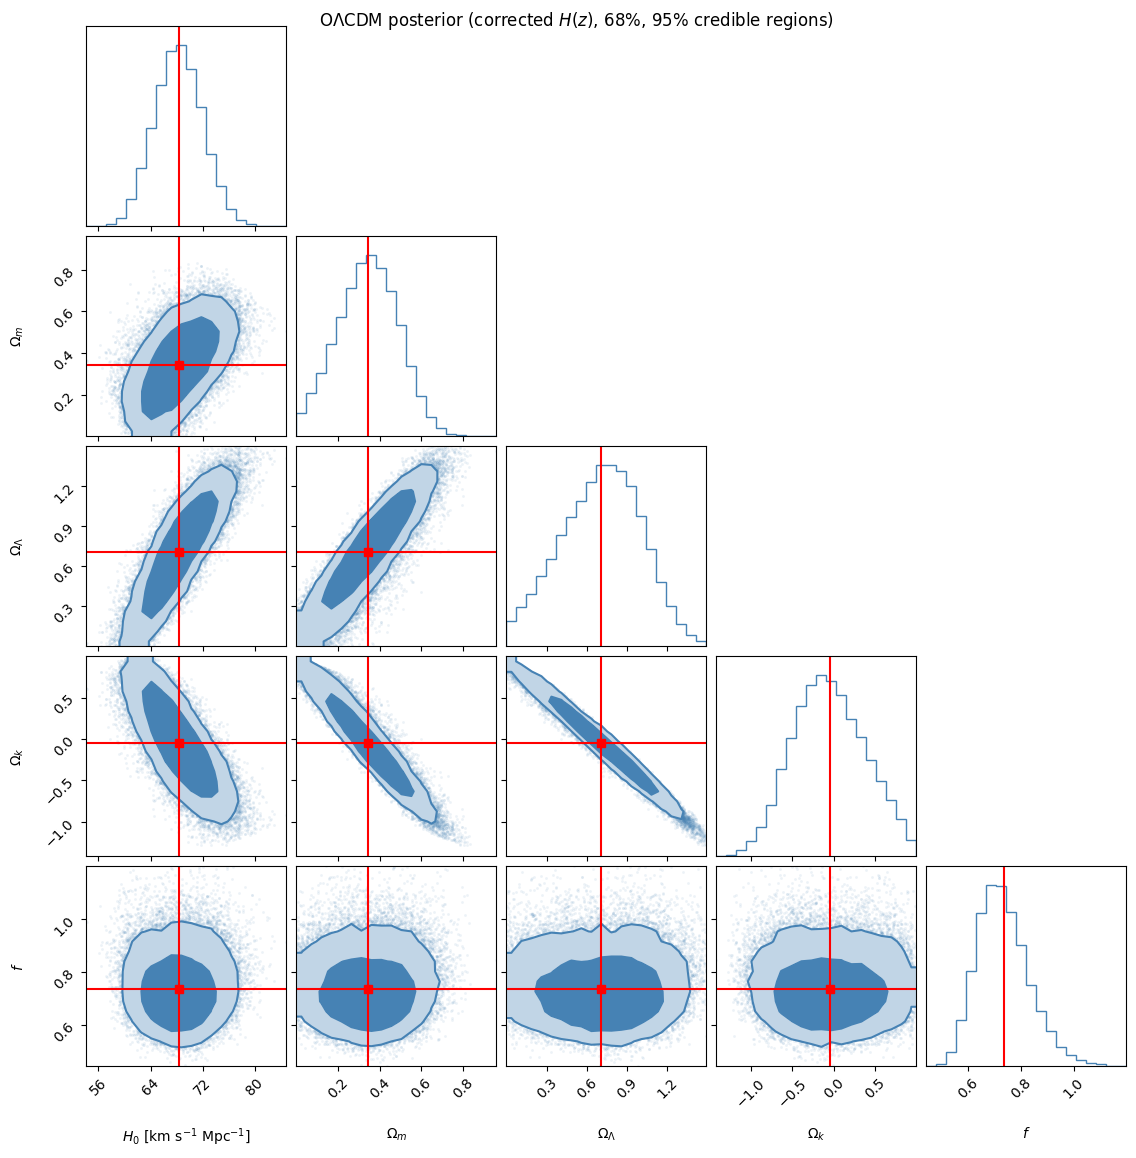

In [ ]:
samples_open = np.column_stack((
    H0_samples_open,
    Omega_m_samples_open,
    Omega_L_samples_open,
    Omega_k_samples_open,
    f_samples_open
))

fig = corner.corner(
    samples_open,
    labels=[
        r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]",
        r"$\Omega_m$",
        r"$\Omega_\Lambda$",
        r"$\Omega_k$",
        r"$f$"
    ],
    truths=[
        H0_open["center"],
        Omega_m_open["center"],
        Omega_L_open["center"],
        Omega_k_open["center"],
        f_open["center"]
    ],
    truth_color='red',
    color='steelblue',
    levels=[0.68, 0.95],
    fill_contours=True
)

fig.suptitle(r"O$\Lambda$CDM posterior (corrected $H(z)$, 68%, 95% credible regions)",)

plt.show()
